In [1]:
from Functions import utils as u

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
data = u.extract_data(UMP_threshold=-3.)

display(data)

#features_and_label = ['Teff', 'NUVDered','logg','bp_rp_dered','UMP_flag']
features_and_label = ['Teff','logg', 'bp_rp_dered', 'colorColorY','UMP_flag']
selected_data = data[features_and_label].copy()

#remove all rows where logg is Nan
#selected_data = selected_data.dropna(subset=['logg'])

print(f"Num of UMPs: {len(selected_data[selected_data['UMP_flag']==1])}")


,Survey,FeH,NUVDered,bp_rp_dered,Teff,logg,colorColorY,UMP_flag
0,Bonifacio,-2.83,20.194627,1.003094,6303,4.25,-1.016775,0
1,Lai,-3.00,21.265522,0.737908,4805,1.48,-0.965118,1
2,Lai,-3.50,21.244102,0.775386,4750,1.31,-0.109841,1
3,Lai,-2.90,20.176450,1.003778,5163,2.47,-0.312304,0
4,Lai,-3.95,22.584123,1.754697,4827,1.51,-8.287684,1
...,...,...,...,...,...,...,...,...
485,Yong,-2.60,18.570030,0.582178,6507,4.29,-1.297989,0
486,Yong,-2.65,17.412597,0.570395,6624,4.11,-1.041163,0
487,Yong,-2.60,18.019629,0.580172,6479,4.31,-1.252573,0
488,Yong,-2.68,18.129256,0.664409,6196,3.77,-1.605187,0


Num of UMPs: 166


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


def scale_and_split(data, target_column, test_size=0.2, random_state=42):
    """
    Splits the dataset into training and validation sets, and scales the features.

    Parameters:
    - data: pd.DataFrame
    - target_column: str, name of the target column
    - test_size: float, proportion of validation set
    - random_state: int, for reproducibility

    Returns:
    - X_train_scaled, X_val_scaled, y_train, y_val, scaler
    """
    # Separate features and target
    X = data.drop(columns=[target_column]).copy()
    y = data[target_column].copy()

    # Split into train and validation
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    # Scale features
    # scaler = StandardScaler()
    # X_train_scaled = scaler.fit_transform(X_train)
    # X_val_scaled = scaler.transform(X_val)

    return X_train, X_val, y_train, y_val,

x_train, x_val, y_train, y_val,= scale_and_split(selected_data, 'UMP_flag',)



In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

from sklearn.metrics import precision_score, recall_score, confusion_matrix




def tune_logistic_regression(X_train, X_val, y_train, y_val, C_values=None,threshold=0.85, patience= 5):
    """
    Trains logistic regression models over a range of C values and plots accuracy.

    Parameters:
    - X_train, X_val: scaled feature arrays
    - y_train, y_val: target arrays
    - C_values: list or array of regularization strengths to try

    Returns:
    - best_model: trained LogisticRegression instance with best C
    """
    if C_values is None:
        C_values = np.logspace(-4, 2, 30)

    best_acc = 0
    best_model = None
    wait = 0
    accuracies = []
    models =[]



    for C in C_values:
        #model = LogisticRegression(C=C, solver='liblinear', max_iter=1000,class_weight={0:1,1:25})
        model = LogisticRegression(C=C, solver='liblinear', max_iter=1000,class_weight='balanced')
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        acc = accuracy_score(y_val, y_pred)
        accuracies.append(acc)
        models.append(model)
        y_proba = model.predict_proba(X_val)[:, 1]
        y_pred = (y_proba >= threshold).astype(int)

        if acc > best_acc:
            best_acc = acc
            best_model = model
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping triggered at C={C:.4f} for regularization tuning.")
                break


    # Plot accuracy vs C
    
    print("Precision:", precision_score(y_val, y_pred))
    print("Recall:", recall_score(y_val, y_pred))
    print(confusion_matrix(y_val, y_pred))

    
    
    plt.figure(figsize=(8, 5))
    plt.semilogx(C_values[:len(accuracies)], accuracies, marker='o')
    plt.xlabel("Regularization Strength (C)")
    plt.ylabel("Validation Accuracy")
    plt.title("Logistic Regression Hyperparameter Tuning")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Best model
    best_idx = np.argmax(accuracies)
    best_model = models[best_idx]
    print(f"Best C: {C_values[best_idx]:.4f} | Accuracy: {accuracies[best_idx]:.4f}")

    # Confusion matrix
    y_pred_best = best_model.predict(X_val)
    cm = confusion_matrix(y_val, y_pred_best)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title("Confusion Matrix (Best Model)")
    plt.show()

    return best_model



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.experimental import enable_halving_search_cv  # noqa
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.metrics import (
    precision_recall_curve, 
    precision_score, recall_score, confusion_matrix, 
    ConfusionMatrixDisplay
)
from imblearn.combine import SMOTEENN


def UMP_predictor_model(X_train, y_train, X_valid, y_valid, target_precision=0.90):
    """
    Logistic Regression optimized for high precision using SMOTEENN + threshold tuning.
    """

    # -------------------------
    # 1. SMOTEENN Resampling
    # -------------------------
    smote_enn = SMOTEENN(random_state=42)
    X_train_res, y_train_res = smote_enn.fit_resample(X_train, y_train)

    # -------------------------
    # 2. Scale data
    # -------------------------
    scaler = StandardScaler()
    X_train_res = scaler.fit_transform(X_train_res)
    X_valid_scaled = scaler.transform(X_valid)

    # -------------------------
    # 3. Model + Halving Grid Search
    # -------------------------
    model = LogisticRegression(
        #class_weight={0: 1, 1: 50},
        solver='lbfgs',
        max_iter=10000
    )

    param_grid = {'C': np.logspace(-1, 2, 40), 'class_weight':[{0:1,1:50},{0:1,1:500},{0:1,1:10},{0:1,1:25},{0:1,1:100}]}

    search = HalvingGridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring='precision',
        cv=5,
        factor=3,
        verbose=1
    )

    search.fit(X_train_res, y_train_res)
    best_model = search.best_estimator_
    print(f"\nBest C: {search.best_params_['C']:.5f}")

    # -------------------------
    # 4. Validation Predictions
    # -------------------------
    y_probs = best_model.predict_proba(X_valid_scaled)[:, 1]

    # Compute precision-recall pairs
    precisions, recalls, thresholds = precision_recall_curve(y_valid, y_probs)

    # Select threshold: highest recall among thresholds meeting target precision
    idx = np.where(precisions >= target_precision)[0]
    if len(idx) > 0:
        best_threshold = thresholds[idx[np.argmax(recalls[idx])]-1]
    else:
        best_threshold = 0.5
    
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
    best_index = np.argmax(f1_scores)
    best_threshold = thresholds[best_index] if best_index < len(thresholds) else 0.5

    print(f"Selected Threshold = {best_threshold:.3f}")

    y_pred = (y_probs >= best_threshold).astype(int)

    # -------------------------
    # 5. Evaluation Metrics
    # -------------------------
    print(f"Precision: {precision_score(y_valid, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_valid, y_pred):.4f}")

    cm = confusion_matrix(y_valid, y_pred)
    plt.figure(figsize=(5, 4))
    ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")
    plt.title(f"Confusion Matrix (threshold={best_threshold:.2f})")
    plt.show()

    # -------------------------
    # 6. Precision vs C Plot
    # -------------------------
    mean_test_scores = search.cv_results_['mean_test_score']
    C_values = search.cv_results_['param_C'].data.astype(float)

    plt.figure(figsize=(7, 5))
    plt.semilogx(C_values, mean_test_scores, marker='o')
    plt.xlabel("Regularization Strength C (log scale)")
    plt.ylabel("CV Precision")
    plt.title("Precision vs Regularization Strength (C)")
    plt.grid(True)
    plt.show()

    # -------------------------
    # 7. Precision-Recall Curve
    # -------------------------
    plt.figure(figsize=(7, 5))
    plt.plot(recalls, precisions)
    
    plt.scatter(recalls[best_index], precisions[best_index], color='red', s=80,
                label=f"Best Threshold = {best_threshold:.3f}")
    
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision–Recall Curve")
    plt.grid(True)
    plt.show()

    return best_model, best_threshold, scaler


n_iterations: 2
n_required_iterations: 5
n_possible_iterations: 2
min_resources_: 20
max_resources_: 130
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 200
n_resources: 20
Fitting 5 folds for each of 200 candidates, totalling 1000 fits
----------
iter: 1
n_candidates: 67
n_resources: 60
Fitting 5 folds for each of 67 candidates, totalling 335 fits

Best C: 28.94266
Selected Threshold = 0.971
Precision: 0.5455
Recall:    0.7273


<Figure size 500x400 with 0 Axes>

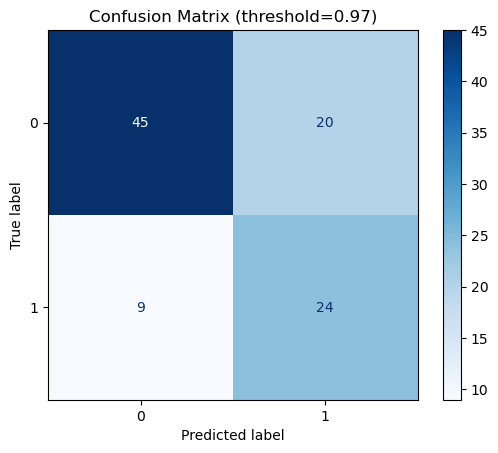

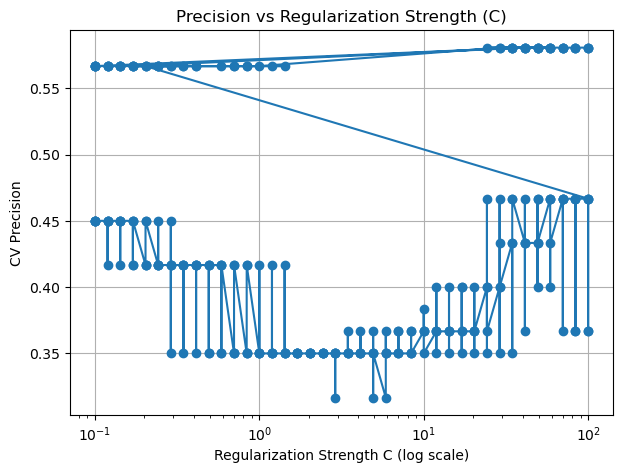

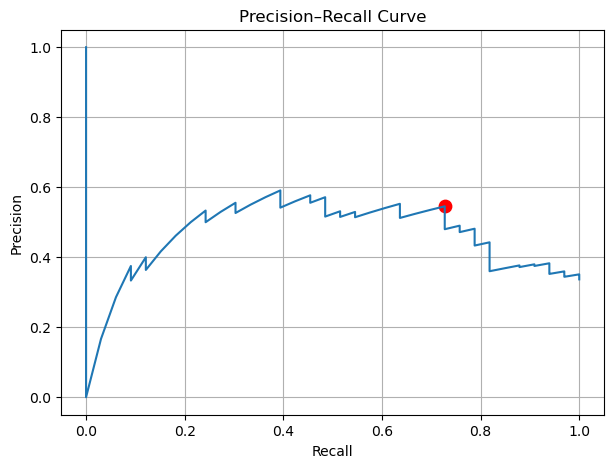

In [ ]:
# Assuming you already have X_train_scaled, X_val_scaled, y_train, y_val
best_model,best_threshold, scaler = UMP_predictor_model(x_train, y_train, x_val, y_val,target_precision=0.60)


In [ ]:
#Create parameter space plots

groups = 

In [7]:
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns

# from sklearn.preprocessing import StandardScaler
# from sklearn.experimental import enable_halving_search_cv  # noqa
# from sklearn.model_selection import HalvingGridSearchCV
# from sklearn.metrics import (
#     precision_recall_curve,
#     precision_score, recall_score, confusion_matrix,
#     ConfusionMatrixDisplay
# )

# from imblearn.over_sampling import ADASYN
# from xgboost import XGBClassifier


# def UMP_predictor_model(X_train, y_train, X_valid, y_valid, target_precision=0.90):
#     """
#     High-precision classifier using ADASYN + XGBoost + threshold tuning.
#     """

#     # -------------------------
#     # 1. Oversample Hard Minority Regions with ADASYN
#     # -------------------------
#     adasyn = ADASYN(random_state=42, n_neighbors=5)
#     X_train_res, y_train_res = adasyn.fit_resample(X_train, y_train)

#     # -------------------------
#     # 2. Scale data AFTER resampling
#     # -------------------------
#     scaler = StandardScaler()
#     X_train_res = scaler.fit_transform(X_train_res)
#     X_valid_scaled = scaler.transform(X_valid)

#     # -------------------------
#     # 3. Model + Halving Grid Search
#     # -------------------------
#     # Class imbalance adjustment for XGBoost
#     scale_pos_weight = (y_train_res == 0).sum() / (y_train_res == 1).sum()

#     base_model = XGBClassifier(
#         scale_pos_weight=scale_pos_weight,
#         eval_metric="logloss",
#     )

#     param_grid = {
#         "max_depth": [2, 3, 4, 5],
#         "learning_rate": [0.01],
#         "n_estimators": [100, 200, 300],
#         "subsample": [0.7, 0.9, 1.0],
#         "colsample_bytree": [0.7, 1.0]
#     }

#     search = HalvingGridSearchCV(
#         estimator=base_model,
#         param_grid=param_grid,
#         scoring="precision",
#         cv=5,
#         factor=3,
#         verbose=1
#     )

#     search.fit(X_train_res, y_train_res)
#     best_model = search.best_estimator_

#     print("\nBest Hyperparameters Found:")
#     print(search.best_params_)

#     # -------------------------
#     # 4. Validation Probability Scores
#     # -------------------------
#     y_probs = best_model.predict_proba(X_valid_scaled)[:, 1]

#     precisions, recalls, thresholds = precision_recall_curve(y_valid, y_probs)

#     # Pick threshold: highest recall such that precision >= target_precision
#     idx = np.where(precisions >= target_precision)[0]
#     if len(idx) > 0:
#         i = idx[np.argmax(recalls[idx])]
#         best_threshold = thresholds[i] if i < len(thresholds) else 0.5
#     else:
#         best_threshold = 0.5

#     print(f"\nSelected Threshold = {best_threshold:.3f}")

#     y_pred = (y_probs >= best_threshold).astype(int)

#     # -------------------------
#     # 5. Performance Evaluation
#     # -------------------------
#     print(f"Precision: {precision_score(y_valid, y_pred):.4f}")
#     print(f"Recall:    {recall_score(y_valid, y_pred):.4f}")

#     cm = confusion_matrix(y_valid, y_pred)
#     plt.figure(figsize=(5, 4))
#     ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")
#     plt.title(f"Confusion Matrix (threshold={best_threshold:.2f})")
#     plt.show()

#     # -------------------------
#     # 6. Precision-Recall Curve
#     # -------------------------
#     plt.figure(figsize=(7, 5))
#     plt.plot(recalls, precisions)
#     plt.xlabel("Recall")
#     plt.ylabel("Precision")
#     plt.title("Precision–Recall Curve (XGBoost + ADASYN)")
#     plt.grid(True)
#     plt.show()

#     return best_model, scaler, best_threshold


In [8]:
# # Assuming you already have X_train_scaled, X_val_scaled, y_train, y_val
# best_model,scaler, best_threshold = UMP_predictor_model(x_train, y_train, x_val, y_val,target_precision=0.80)


In [9]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score
import numpy as np

y_proba = best_model.predict_proba(x_val)[:,1]
y_pred_05 = (y_proba >= 0.5).astype(int)

print("Precision at 0.5:", precision_score(y_val, y_pred_05, zero_division=0))
print("Recall at 0.5:", recall_score(y_val, y_pred_05, zero_division=0))
print("Confusion matrix:\n", confusion_matrix(y_val, y_pred_05))

print("Positives predicted:", y_pred_05.sum())
print("Proba stats (positives only):", np.percentile(y_proba[y_val==1], [0,25,50,75,100]))
print("Proba stats (negatives):", np.percentile(y_proba[y_val==0], [0,25,50,75,100]))

print()
y_pred_t = (y_proba >= best_threshold).astype(int)

print("Precision at best t:", precision_score(y_val, y_pred_t, zero_division=0))
print("Recall at best t:", recall_score(y_val, y_pred_t, zero_division=0))
print("Confusion matrix:\n", confusion_matrix(y_val, y_pred_t))


# distribution of probabilities

print("Positives predicted:", y_pred_t.sum())
print("Proba stats (positives only):", np.percentile(y_proba[y_val==1], [0,25,50,75,100]))
print("Proba stats (negatives):", np.percentile(y_proba[y_val==0], [0,25,50,75,100]))


Precision at 0.5: 0.336734693877551
Recall at 0.5: 1.0
Confusion matrix:
 [[ 0 65]
 [ 0 33]]
Positives predicted: 98
Proba stats (positives only): [1. 1. 1. 1. 1.]
Proba stats (negatives): [1. 1. 1. 1. 1.]

Precision at best t: 0.336734693877551
Recall at best t: 1.0
Confusion matrix:
 [[ 0 65]
 [ 0 33]]
Positives predicted: 98
Proba stats (positives only): [1. 1. 1. 1. 1.]
Proba stats (negatives): [1. 1. 1. 1. 1.]


c:\Users\fderi\.conda\envs\sciML\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay,
    make_scorer
)


def UMP_predictor_ffnn_model(X_train, y_train, X_val, y_val):

    # ---- Scale the data manually (no pipeline) ----
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled   = scaler.transform(X_val)

    # Base MLP model
    model = MLPClassifier(
        activation='relu',
        solver='adam',
        max_iter=10000,
        random_state=42
    )

    # Hyperparameter grid
    param_grid = {
        'hidden_layer_sizes': [
            (128,64),(64,32), (64,32,32), (64,32,32,32),
            (64,64,32), (128,64,32)
        ],
        'alpha': [0.0001, 0.001, 0.01, 0.1]
    }

    # Precision scoring
    precision_scorer = make_scorer(precision_score, zero_division=0)

    # Hyperparameter search
    search = HalvingGridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring=precision_scorer,
        cv=5,
        factor=3,
        verbose=1
    )

    search.fit(X_train_scaled, y_train)
    best_model = search.best_estimator_

    print("\nBest Hyperparameters:", search.best_params_)

    # ---- Get predicted probabilities ----
    y_scores = best_model.predict_proba(X_val_scaled)[:, 1]

    # ---- Find Best Threshold (maximize F1-score) ----
    precisions, recalls, thresholds = precision_recall_curve(y_val, y_scores)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)

    best_index = np.argmax(f1_scores)
    best_threshold = thresholds[best_index] if best_index < len(thresholds) else 0.5

    print(f"\nBest Threshold (max F1): {best_threshold:.4f}")
    print(f"Precision at best threshold: {precisions[best_index]:.4f}")
    print(f"Recall at best threshold: {recalls[best_index]:.4f}")
    print(f"F1-score at best threshold: {f1_scores[best_index]:.4f}")

    # ---- Apply threshold ----
    y_pred = (y_scores >= best_threshold).astype(int)

    # ---- Confusion Matrix ----
    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")
    plt.title("Confusion Matrix (Best Threshold Applied)")
    plt.show()

    # ---- Precision–Recall Curve ----
    plt.figure(figsize=(7,4))
    plt.plot(recalls, precisions, linewidth=2)
    plt.scatter(recalls[best_index], precisions[best_index], color='red', s=80,
                label=f"Best Threshold = {best_threshold:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision–Recall Curve")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ---- Precision vs Network Architecture ----
    results = search.cv_results_
    mean_precisions = results['mean_test_score']
    labels = [str(h) for h in results['param_hidden_layer_sizes']]

    plt.figure(figsize=(10,4))
    plt.plot(labels, mean_precisions, marker='o')
    plt.xticks(rotation=45)
    plt.xlabel("Hidden Layer Sizes")
    plt.ylabel("Cross-Validated Precision")
    plt.title("Precision vs Network Architecture")
    plt.grid(True)
    plt.show()

    return best_model, best_threshold


n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 3
min_resources_: 43
max_resources_: 392
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 24
n_resources: 43
Fitting 5 folds for each of 24 candidates, totalling 120 fits
----------
iter: 1
n_candidates: 8
n_resources: 129
Fitting 5 folds for each of 8 candidates, totalling 40 fits
----------
iter: 2
n_candidates: 3
n_resources: 387
Fitting 5 folds for each of 3 candidates, totalling 15 fits

Best Hyperparameters: {'alpha': 0.1, 'hidden_layer_sizes': (64, 32, 32, 32)}

Best Threshold (max F1): 0.1263
Precision at best threshold: 0.4286
Recall at best threshold: 0.9091
F1-score at best threshold: 0.5825


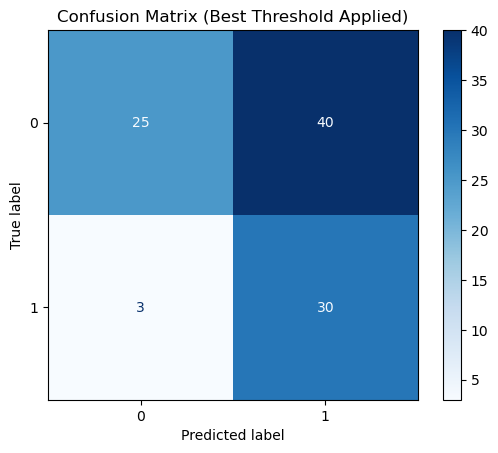

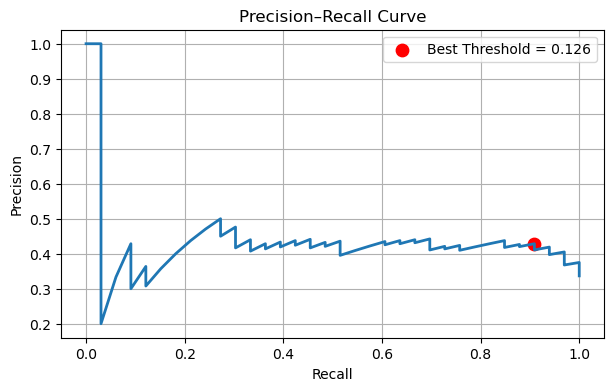

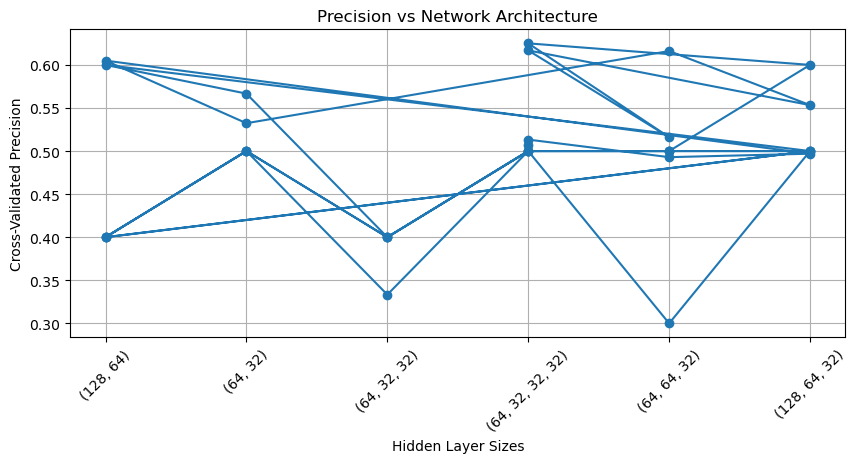

In [11]:
best_model,best_threshold = UMP_predictor_ffnn_model(x_train, y_train, x_val, y_val)

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.metrics import precision_score, confusion_matrix, ConfusionMatrixDisplay, make_scorer


def UMP_predictor_knn_model(X_train, y_train, X_val, y_val):
    # Define base KNN model
    
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val  = scaler.transform(X_val)
    
    model = KNeighborsClassifier()

    # Hyperparameter grid to tune
    param_grid = {
        'n_neighbors': [1, 3, 5, 7, 9, 11],
        'weights': ['uniform', 'distance'],  # uniform = all neighbors equal, distance = closer neighbors matter more
        'p': [1, 2]  # p=1 (Manhattan), p=2 (Euclidean)
    }

    # Precision scorer that avoids NaN warnings
    precision_scorer = make_scorer(precision_score, zero_division=0)

    # Halving search
    search = HalvingGridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring=precision_scorer,
        cv=5,
        factor=3,
        verbose=1
    )

    # Fit search
    search.fit(X_train, y_train)

    # Best KNN model
    best_model = search.best_estimator_
    print("\nBest Hyperparameters:", search.best_params_)

    # Predict + Precision
    y_pred = best_model.predict(X_val)
    final_precision = precision_score(y_val, y_pred, zero_division=0)
    print("Validation Precision:", final_precision)

    # Confusion Matrix
    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")
    plt.title("Confusion Matrix (Best KNN Model)")
    plt.show()

    # --- Performance Plot: Precision vs n_neighbors ---
    results = search.cv_results_
    k_values = results['param_n_neighbors']
    mean_precisions = results['mean_test_score']

    plt.figure(figsize=(7, 4))
    plt.plot(k_values, mean_precisions, marker='o')
    plt.xlabel("n_neighbors (k)")
    plt.ylabel("Cross-Validated Precision")
    plt.title("Precision vs Number of Neighbors (k)")
    plt.grid(True)
    plt.show()

    return best_model


In [ ]:
best_model = UMP_predictor_knn_model(x_train, y_train, x_val, y_val)

n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 3
min_resources_: 43
max_resources_: 392
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 24
n_resources: 43
Fitting 5 folds for each of 24 candidates, totalling 120 fits
----------
iter: 1
n_candidates: 8
n_resources: 129
Fitting 5 folds for each of 8 candidates, totalling 40 fits


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.metrics import precision_score, confusion_matrix, ConfusionMatrixDisplay, make_scorer
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN


def UMP_predictor_knn_smote_model(X_train, y_train, X_val, y_val):
    # ---- SMOTE Oversampling ----
    smote_enn = SMOTEENN(random_state=42)
    X_train_res, y_train_res = smote_enn.fit_resample(X_train, y_train)
    
    #smote = SMOTE(random_state=42)
    #X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    # ---- Scaling (required for KNN) ----
    scaler = StandardScaler()
    X_train_res = scaler.fit_transform(X_train_res)
    X_val = scaler.transform(X_val)

    # ---- Define model ----
    model = KNeighborsClassifier(
        
    )

    # Hyperparameter grid
    
    neighbor_set = np.arange(1, 15)
    
    param_grid = {
        'n_neighbors': neighbor_set,
        'weights': ['distance'],
        'p': [1, 2]  # Manhattan vs Euclidean
    }

    # Example: predict probabilities instead of hard labels


    # Precision scorer
    precision_scorer = make_scorer(precision_score, zero_division=0)

    # Halving Grid Search
    search = HalvingGridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring=precision_scorer,
        cv=5,
        factor=3,
        verbose=1
    )

    # Fit
    search.fit(X_train_res, y_train_res)
    best_model = search.best_estimator_
    
    # Example: predict probabilities instead of hard labels
    y_probs = best_model.predict_proba(X_val)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_val, y_probs)

    
    target_precision = 0.80
    idx = np.where(precision >= target_precision)[0]

    if len(idx) > 0:
        best_threshold = thresholds[idx[np.argmax(recall[idx-1])]-1]  # best recall at req precision
    else:
        best_threshold = 0.5

    print(f"Selected Threshold = {best_threshold:.3f}")

    y_pred = (y_probs >= best_threshold).astype(int)

    plt.plot(recall, precision)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.show()
        

    print("\nBest Hyperparameters:", search.best_params_)

    # ---- Evaluate on validation ----
    #y_pred = best_model.predict(X_val)
    final_precision = precision_score(y_val, y_pred, zero_division=0)
    print("Validation Precision:", final_precision)

    # Confusion Matrix
    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")
    plt.title("Confusion Matrix (KNN + SMOTE)")
    plt.show()

    # Precision vs K plot
    results = search.cv_results_
    k_vals = results['param_n_neighbors']
    mean_precisions = results['mean_test_score']

    plt.figure(figsize=(7, 4))
    plt.plot(k_vals, mean_precisions, marker='o')
    plt.xlabel("n_neighbors (k)")
    plt.ylabel("Cross-Validated Precision")
    plt.title("Precision vs k (after SMOTE)")
    plt.grid(True)
    plt.show()


    return best_model


n_iterations: 2
n_required_iterations: 4
n_possible_iterations: 2
min_resources_: 20
max_resources_: 130
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 28
n_resources: 20
Fitting 5 folds for each of 28 candidates, totalling 140 fits


c:\Users\fderi\.conda\envs\sciML\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


----------
iter: 1
n_candidates: 10
n_resources: 60
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Selected Threshold = 1.000


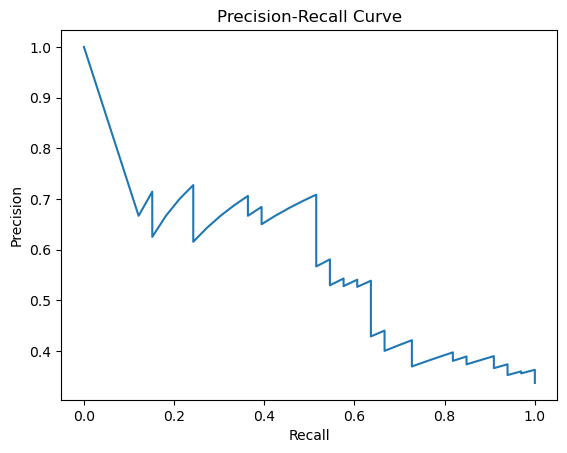


Best Hyperparameters: {'n_neighbors': np.int64(11), 'p': 2, 'weights': 'distance'}
Validation Precision: 0.6666666666666666


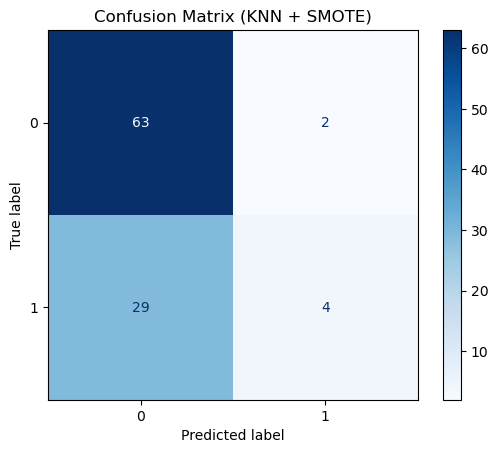

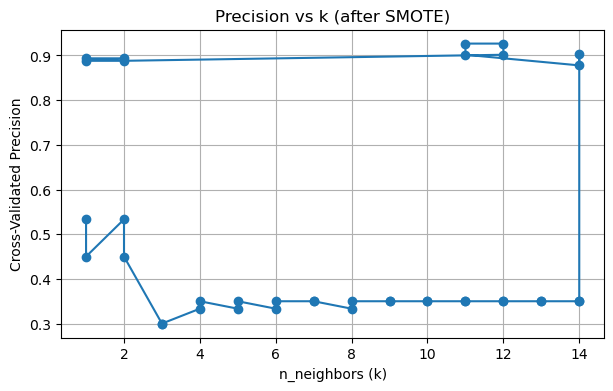

In [ ]:
best_model = UMP_predictor_knn_smote_model(x_train,y_train,x_val,y_val)